# Kaggle Leukemia CNN+Transformer

Self-contained notebook for the Kaggle leukemia classification dataset. No project Python modules are imported; all model, training, metric, and Grad-CAM code is inside this notebook.

In [1]:

from __future__ import annotations

import copy
import json
import math
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from PIL import Image, ImageDraw, ImageFilter, ImageFont
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms

SEED = 42
IMAGE_SIZE = int(os.getenv("KAGGLE_IMAGE_SIZE", "96"))
BATCH_SIZE = int(os.getenv("KAGGLE_BATCH_SIZE", "128"))
EPOCHS = int(os.getenv("KAGGLE_EPOCHS", "100"))
PATIENCE = int(os.getenv("KAGGLE_PATIENCE", str(EPOCHS)))
LEARNING_RATE = float(os.getenv("KAGGLE_LR", "4e-4"))
WEIGHT_DECAY = float(os.getenv("KAGGLE_WEIGHT_DECAY", "1e-4"))
NUM_THREADS = min(8, max(1, os.cpu_count() or 1))
torch.set_num_threads(NUM_THREADS)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATASET_ROOT = PROJECT_ROOT / "data/raw/kaggle_leukemia_classification/kagglehub_cache/datasets/andrewmvd/leukemia-classification/versions/2/C-NMC_Leukemia"
CLASS_NAMES = ["hem", "all"]
DISPLAY_NAMES = {"hem": "healthy", "all": "leukemia"}
LABEL_TO_NAME = {0: "hem", 1: "all"}
NAME_TO_LABEL = {v: k for k, v in LABEL_TO_NAME.items()}
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Project root:", PROJECT_ROOT)
print("Dataset root:", DATASET_ROOT)
print("Device:", DEVICE)
print("CPU threads:", NUM_THREADS)
print("Image size:", IMAGE_SIZE, "Batch size:", BATCH_SIZE, "Epochs:", EPOCHS)
print("Backbone: compact ResNet-style residual CNN trained on Kaggle C-NMC only")


Project root: /Users/panshulaj/Documents/AIML proj
Dataset root: /Users/panshulaj/Documents/AIML proj/data/raw/kaggle_leukemia_classification/kagglehub_cache/datasets/andrewmvd/leukemia-classification/versions/2/C-NMC_Leukemia
Device: mps
CPU threads: 8
Image size: 96 Batch size: 128 Epochs: 100
Backbone: compact ResNet-style residual CNN trained on Kaggle C-NMC only


## Dataset Inventory

The code below uses the extracted Kaggle dataset only and verifies labeled counts before training.

In [2]:

def patient_id_from_original_name(name: str) -> str:
    stem = Path(name).stem
    parts = stem.split("_")
    if len(parts) >= 2 and parts[0].lower() == "uid":
        return parts[1]
    return parts[0]


def build_training_frame(dataset_root: Path) -> pd.DataFrame:
    rows = []
    train_root = dataset_root / "training_data"
    for fold_dir in sorted(train_root.glob("fold_*")):
        for class_name, label in NAME_TO_LABEL.items():
            class_dir = fold_dir / class_name
            for path in sorted(class_dir.glob("*.bmp")):
                rows.append(
                    {
                        "path": str(path.resolve()),
                        "label": label,
                        "class_name": class_name,
                        "display_class": DISPLAY_NAMES[class_name],
                        "patient_id": patient_id_from_original_name(path.name),
                        "source_split": "training_data",
                        "source_fold": fold_dir.name,
                    }
                )
    return pd.DataFrame(rows)


def build_test_frame(dataset_root: Path) -> pd.DataFrame:
    labels_path = dataset_root / "validation_data" / "C-NMC_test_prelim_phase_data_labels.csv"
    image_dir = dataset_root / "validation_data" / "C-NMC_test_prelim_phase_data"
    labels = pd.read_csv(labels_path)
    rows = []
    for row in labels.itertuples(index=False):
        label = int(row.labels)
        class_name = LABEL_TO_NAME[label]
        path = image_dir / str(row.new_names)
        rows.append(
            {
                "path": str(path.resolve()),
                "label": label,
                "class_name": class_name,
                "display_class": DISPLAY_NAMES[class_name],
                "patient_id": patient_id_from_original_name(str(row.Patient_ID)),
                "source_split": "validation_data_labeled_test",
                "source_fold": "prelim_phase",
                "original_name": str(row.Patient_ID),
            }
        )
    return pd.DataFrame(rows)


train_full = build_training_frame(DATASET_ROOT)
test_df = build_test_frame(DATASET_ROOT)
unlabeled_final_dir = DATASET_ROOT / "testing_data" / "C-NMC_test_final_phase_data"
unlabeled_final_count = len(list(unlabeled_final_dir.glob("*.bmp")))

patient_table = train_full.groupby("patient_id", as_index=False)["label"].first()
train_patients, val_patients = train_test_split(
    patient_table,
    test_size=0.15,
    random_state=SEED,
    stratify=patient_table["label"],
)
train_df = train_full[train_full["patient_id"].isin(set(train_patients["patient_id"]))].reset_index(drop=True)
val_df = train_full[train_full["patient_id"].isin(set(val_patients["patient_id"]))].reset_index(drop=True)

summary = pd.DataFrame(
    {
        "split": ["train", "val", "labeled_test", "unlabeled_final_ignored"],
        "images": [len(train_df), len(val_df), len(test_df), unlabeled_final_count],
        "healthy_hem": [int((train_df.label == 0).sum()), int((val_df.label == 0).sum()), int((test_df.label == 0).sum()), None],
        "leukemia_all": [int((train_df.label == 1).sum()), int((val_df.label == 1).sum()), int((test_df.label == 1).sum()), None],
        "patient_groups": [train_df.patient_id.nunique(), val_df.patient_id.nunique(), test_df.patient_id.nunique(), None],
    }
)
display(summary)

assert DATASET_ROOT.exists(), f"Missing dataset root: {DATASET_ROOT}"
assert len(train_full) == 10661, f"Expected 10661 training images, found {len(train_full)}"
assert len(test_df) == 1867, f"Expected 1867 labeled validation/test images, found {len(test_df)}"
assert train_df["path"].map(lambda p: Path(p).exists()).all()
assert val_df["path"].map(lambda p: Path(p).exists()).all()
assert test_df["path"].map(lambda p: Path(p).exists()).all()


,split,images,healthy_hem,leukemia_all,patient_groups
0,train,8958,2742.0,6216.0,62.0
1,val,1703,647.0,1056.0,11.0
2,labeled_test,1867,648.0,1219.0,28.0
3,unlabeled_final_ignored,2586,NaN,NaN,NaN


## Preprocessing and DataLoaders

Images are white-balanced, contrast-stretched, resized, augmented for training, normalized from the training split only, and sampled with class balancing.

In [3]:

class MicroscopyPreprocess:
    """Deterministic stain/illumination normalization for cell crops."""

    def __init__(self, low: float = 0.5, high: float = 99.5, gamma: float = 0.95, sharpen: bool = True):
        self.low = low
        self.high = high
        self.gamma = gamma
        self.sharpen = sharpen

    def __call__(self, image: Image.Image) -> Image.Image:
        arr = np.asarray(image.convert("RGB"), dtype=np.float32) / 255.0
        channel_means = arr.reshape(-1, 3).mean(axis=0, keepdims=True)
        gray_mean = channel_means.mean()
        arr = arr * (gray_mean / np.maximum(channel_means, 1e-4)).reshape(1, 1, 3)
        lo = np.percentile(arr, self.low, axis=(0, 1), keepdims=True)
        hi = np.percentile(arr, self.high, axis=(0, 1), keepdims=True)
        arr = (arr - lo) / np.maximum(hi - lo, 1e-4)
        arr = np.clip(arr, 0.0, 1.0)
        arr = np.power(arr, self.gamma)
        out = Image.fromarray((arr * 255).astype(np.uint8))
        if self.sharpen:
            out = out.filter(ImageFilter.UnsharpMask(radius=1.0, percent=110, threshold=3))
        return out


class RandomGaussianNoise:
    def __init__(self, std: float = 0.010, p: float = 0.20):
        self.std = std
        self.p = p

    def __call__(self, tensor: torch.Tensor) -> torch.Tensor:
        if random.random() >= self.p:
            return tensor
        return torch.clamp(tensor + torch.randn_like(tensor) * self.std, 0.0, 1.0)


base_preprocess = transforms.Compose([
    MicroscopyPreprocess(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=transforms.InterpolationMode.BICUBIC),
])


def image_to_uint8_tensor(image: Image.Image) -> torch.Tensor:
    arr = np.asarray(base_preprocess(image).convert("RGB"), dtype=np.uint8)
    return torch.from_numpy(arr).permute(2, 0, 1).contiguous()


def cache_uint8_images(frame: pd.DataFrame, name: str) -> list[torch.Tensor]:
    cached = []
    total = len(frame)
    for index, row in enumerate(frame.itertuples(index=False), start=1):
        with Image.open(row.path) as image:
            cached.append(image_to_uint8_tensor(image))
        if index == 1 or index == total or index % 1000 == 0:
            print(f"cached {name}: {index}/{total}", flush=True)
    return cached


def compute_mean_std_from_cache(cache: list[torch.Tensor]) -> tuple[list[float], list[float]]:
    channel_sum = torch.zeros(3)
    channel_sq_sum = torch.zeros(3)
    pixels = 0
    for byte_tensor in cache:
        tensor = byte_tensor.float().div(255.0)
        channel_sum += tensor.sum(dim=(1, 2))
        channel_sq_sum += (tensor ** 2).sum(dim=(1, 2))
        pixels += tensor.shape[1] * tensor.shape[2]
    mean = channel_sum / pixels
    variance = channel_sq_sum / pixels - mean ** 2
    std = torch.sqrt(torch.clamp(variance, min=1e-8))
    return mean.tolist(), std.tolist()


train_cache = cache_uint8_images(train_df, "train")
val_cache = cache_uint8_images(val_df, "val")
test_cache = cache_uint8_images(test_df, "labeled_test")
mean, std = compute_mean_std_from_cache(train_cache)
print("Train normalization mean:", [round(x, 6) for x in mean])
print("Train normalization std:", [round(x, 6) for x in std])

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.76, 1.0),
        ratio=(0.92, 1.08),
        interpolation=transforms.InterpolationMode.BILINEAR,
        antialias=True,
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.06, 0.06),
        scale=(0.92, 1.10),
        shear=4,
        interpolation=transforms.InterpolationMode.BILINEAR,
    ),
    transforms.RandomAutocontrast(p=0.30),
    transforms.RandomAdjustSharpness(sharpness_factor=1.5, p=0.20),
    transforms.ColorJitter(brightness=0.16, contrast=0.16, saturation=0.10, hue=0.012),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.7))], p=0.08),
    RandomGaussianNoise(std=0.010, p=0.20),
    transforms.Normalize(mean=mean, std=std),
    transforms.RandomErasing(p=0.14, scale=(0.012, 0.045), ratio=(0.5, 2.0), value=0.0),
])

eval_transform = transforms.Compose([
    transforms.Normalize(mean=mean, std=std),
])

plain_transform = transforms.Compose([])


class LeukemiaDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, cached_images: list[torch.Tensor], transform=None):
        self.frame = frame.reset_index(drop=True)
        self.cached_images = cached_images
        self.transform = transform

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, index: int):
        row = self.frame.iloc[index]
        image = self.cached_images[index].float().div(255.0)
        if self.transform is not None:
            image = self.transform(image)
        return image, int(row.label), row.path


train_counts = train_df["label"].value_counts().sort_index()
sample_weights = train_df["label"].map(lambda label: 1.0 / train_counts[int(label)]).to_numpy()
sampler_generator = torch.Generator().manual_seed(SEED)
sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
    generator=sampler_generator,
)

train_dataset = LeukemiaDataset(train_df, train_cache, train_transform)
val_dataset = LeukemiaDataset(val_df, val_cache, eval_transform)
test_dataset = LeukemiaDataset(test_df, test_cache, eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=0,
    pin_memory=PIN_MEMORY,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY,
)

batch_images, batch_labels, batch_paths = next(iter(train_loader))
print("Batch tensor:", tuple(batch_images.shape), "Batch labels:", batch_labels[:8].tolist())


cached train: 1/8958


/var/folders/fn/y2r7tz8s7m988x6s6msf6ndr0000gn/T/ipykernel_9460/995016779.py:45: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  return torch.from_numpy(arr).permute(2, 0, 1).contiguous()


cached train: 1000/8958


cached train: 2000/8958


cached train: 3000/8958


...

cached labeled_test: 1/1867


cached labeled_test: 1000/1867


cached labeled_test: 1867/1867


Train normalization mean: [0.124185, 0.095022, 0.132939]
Train normalization std: [0.279825, 0.218818, 0.2982]


Batch tensor: (128, 3, 96, 96) Batch labels: [0, 0, 0, 0, 0, 0, 1, 1]


## Compact ResNet CNN+Transformer Architecture

This model uses a compact ResNet-style residual CNN backbone trained on the Kaggle C-NMC images, then converts the final spatial feature map into transformer tokens. No external pretrained image weights are used.

In [4]:

class ResidualBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1, dropout: float = 0.04):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.act = nn.GELU()
        self.dropout = nn.Dropout2d(dropout)
        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = self.shortcut(x)
        out = self.act(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        return self.act(out + identity)


class CompactResNetBackbone(nn.Module):
    def __init__(self, channels: tuple[int, int, int, int] = (32, 64, 128, 192)):
        super().__init__()
        c1, c2, c3, c4 = channels
        self.stem = nn.Sequential(
            nn.Conv2d(3, c1, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c1),
            nn.GELU(),
        )
        self.stage1 = nn.Sequential(ResidualBlock(c1, c1), ResidualBlock(c1, c1))
        self.stage2 = nn.Sequential(ResidualBlock(c1, c2, stride=2), ResidualBlock(c2, c2))
        self.stage3 = nn.Sequential(ResidualBlock(c2, c3, stride=2), ResidualBlock(c3, c3))
        self.stage4 = nn.Sequential(ResidualBlock(c3, c4, stride=2), ResidualBlock(c4, c4))
        self.out_channels = c4

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        return x


class CNNTransformer(nn.Module):
    def __init__(self, image_size: int = IMAGE_SIZE, embed_dim: int = 96, heads: int = 4, layers: int = 2, num_classes: int = 2):
        super().__init__()
        self.backbone = CompactResNetBackbone()
        self.target_layer = self.backbone.stage4
        with torch.no_grad():
            features = self.backbone(torch.zeros(1, 3, image_size, image_size))
        feature_h, feature_w = int(features.shape[-2]), int(features.shape[-1])
        token_count = feature_h * feature_w
        self.feature_shape = (feature_h, feature_w)
        self.projection = nn.Sequential(
            nn.Conv2d(self.backbone.out_channels, embed_dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(embed_dim),
            nn.GELU(),
        )
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.position = nn.Parameter(torch.zeros(1, token_count + 1, embed_dim))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.18,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=layers)
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Dropout(0.30),
            nn.Linear(embed_dim, num_classes),
        )
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.position, std=0.02)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.backbone(x)
        tokens = self.projection(features).flatten(2).transpose(1, 2)
        cls = self.cls_token.expand(tokens.shape[0], -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)
        tokens = tokens + self.position[:, : tokens.shape[1]]
        encoded = self.transformer(tokens)
        return self.head(encoded[:, 0])


model = CNNTransformer().to(DEVICE)
print(model)
print("Feature map for graph/tokens:", model.feature_shape)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


CNNTransformer(
  (backbone): CompactResNetBackbone(
    (stem): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): GELU(approximate='none')
    )
    (stage1): Sequential(
      (0): ResidualBlock(
        (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (act): GELU(approximate='none')
        (dropout): Dropout2d(p=0.04, inplace=False)
        (shortcut): Identity()
      )
      (1): ResidualBlock(
        (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1

/var/folders/fn/y2r7tz8s7m988x6s6msf6ndr0000gn/T/ipykernel_9460/3056993631.py:75: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=layers)


## Training, Evaluation, and Grad-CAM

The best validation-balanced checkpoint from this notebook run is evaluated on the labeled Kaggle validation split, then Grad-CAM overlays are generated for selected mistakes and correct examples.

In [5]:

def class_weights_from_frame(frame: pd.DataFrame) -> torch.Tensor:
    counts = frame["label"].value_counts().sort_index().to_numpy(dtype=np.float32)
    weights = counts.sum() / (len(counts) * counts)
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


def forward_with_tta(model: nn.Module, images: torch.Tensor) -> torch.Tensor:
    variants = [
        images,
        torch.flip(images, dims=[3]),
        torch.flip(images, dims=[2]),
        torch.flip(images, dims=[2, 3]),
    ]
    logits = [model(variant) for variant in variants]
    return torch.stack(logits, dim=0).mean(dim=0)


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, criterion: nn.Module | None = None, use_tta: bool = False) -> dict:
    model.eval()
    losses = []
    y_true, y_prob, paths = [], [], []
    for images, labels, batch_paths in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        logits = forward_with_tta(model, images) if use_tta else model(images)
        if criterion is not None:
            losses.append(float(criterion(logits, labels).detach().cpu()))
        probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
        y_prob.extend(probs.tolist())
        y_true.extend(labels.detach().cpu().numpy().tolist())
        paths.extend(list(batch_paths))
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        "loss": float(np.mean(losses)) if losses else np.nan,
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred,
        "paths": paths,
    }


def state_dict_to_cpu(model: nn.Module) -> dict[str, torch.Tensor]:
    return {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}


def train_one_epoch(model: nn.Module, loader: DataLoader, criterion: nn.Module, optimizer: torch.optim.Optimizer) -> dict:
    model.train()
    losses = []
    y_true, y_pred = [], []
    for images, labels, _ in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        losses.append(float(loss.detach().cpu()))
        y_true.extend(labels.detach().cpu().numpy().tolist())
        y_pred.extend(logits.argmax(dim=1).detach().cpu().numpy().tolist())
    return {"loss": float(np.mean(losses)), "accuracy": accuracy_score(y_true, y_pred)}


def best_threshold(y_true: np.ndarray, y_prob: np.ndarray) -> tuple[float, float]:
    thresholds = np.linspace(0.05, 0.95, 181)
    scores = [balanced_accuracy_score(y_true, (y_prob >= threshold).astype(int)) for threshold in thresholds]
    index = int(np.argmax(scores))
    return float(thresholds[index]), float(scores[index])


def summarize_predictions(y_true: np.ndarray, y_prob: np.ndarray, threshold: float) -> tuple[dict, np.ndarray]:
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "threshold": float(threshold),
        "samples": int(len(y_true)),
        "hem_healthy_support": int((y_true == 0).sum()),
        "all_leukemia_support": int((y_true == 1).sum()),
        "confusion_hem_hem": int(cm[0, 0]),
        "confusion_hem_all": int(cm[0, 1]),
        "confusion_all_hem": int(cm[1, 0]),
        "confusion_all_all": int(cm[1, 1]),
    }
    return metrics, y_pred


def fit_model(model: nn.Module, out_dir: Path) -> tuple[nn.Module, pd.DataFrame, dict, pd.DataFrame]:
    out_dir.mkdir(parents=True, exist_ok=True)
    metrics_path = out_dir / "metrics.json"
    history_path = out_dir / "training_history.csv"
    predictions_path = out_dir / "predictions.csv"
    state_path = out_dir / "best_model_state.pt"
    if metrics_path.exists() and history_path.exists() and predictions_path.exists() and state_path.exists():
        metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
        history_df = pd.read_csv(history_path)
        if int(metrics.get("epochs_requested", -1)) == EPOCHS and int(metrics.get("epochs_ran", -1)) == EPOCHS and len(history_df) == EPOCHS:
            print(f"Using completed saved {EPOCHS}-epoch run from: {out_dir}", flush=True)
            state = torch.load(state_path, map_location="cpu")
            model.load_state_dict({key: value.to(DEVICE) for key, value in state.items()})
            predictions = pd.read_csv(predictions_path)
            return model, history_df, metrics, predictions
    criterion = nn.CrossEntropyLoss(weight=class_weights_from_frame(train_df), label_smoothing=0.03)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(1, EPOCHS),
        eta_min=LEARNING_RATE * 0.03,
    )

    best_state = state_dict_to_cpu(model)
    best_score = -1.0
    best_epoch = 0
    best_val_threshold = 0.5
    history = []
    wait = 0
    start = time.time()

    for epoch in range(1, EPOCHS + 1):
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer)
        val_eval = evaluate(model, val_loader, criterion, use_tta=False)
        threshold, val_balanced = best_threshold(val_eval["y_true"], val_eval["y_prob"])
        val_pred = (val_eval["y_prob"] >= threshold).astype(int)
        val_accuracy = accuracy_score(val_eval["y_true"], val_pred)
        scheduler.step()
        lr = optimizer.param_groups[0]["lr"]
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_accuracy": train_metrics["accuracy"],
                "val_loss": val_eval["loss"],
                "val_accuracy": float(val_accuracy),
                "val_balanced_accuracy": float(val_balanced),
                "val_threshold": float(threshold),
                "learning_rate": float(lr),
            }
        )
        pd.DataFrame(history).to_csv(out_dir / "training_history_live.csv", index=False)
        print(
            f"epoch {epoch:03d}/{EPOCHS} "
            f"train_loss={train_metrics['loss']:.4f} train_acc={train_metrics['accuracy']:.4f} "
            f"val_loss={val_eval['loss']:.4f} val_acc={val_accuracy:.4f} "
            f"val_bal={val_balanced:.4f} thr={threshold:.3f} lr={lr:.2e}",
            flush=True,
        )
        if val_balanced > best_score:
            best_score = float(val_balanced)
            best_epoch = epoch
            best_val_threshold = float(threshold)
            best_state = state_dict_to_cpu(model)
            torch.save(best_state, out_dir / "best_model_state.pt")
            wait = 0
        else:
            wait += 1
        if wait >= PATIENCE:
            print(f"Early stop at epoch {epoch}; best epoch was {best_epoch}.", flush=True)
            break

    model.load_state_dict({key: value.to(DEVICE) for key, value in best_state.items()})
    final_val_eval = evaluate(model, val_loader, criterion, use_tta=True)
    final_threshold, final_val_balanced = best_threshold(final_val_eval["y_true"], final_val_eval["y_prob"])
    test_eval = evaluate(model, test_loader, criterion, use_tta=True)
    test_metrics, test_pred = summarize_predictions(test_eval["y_true"], test_eval["y_prob"], final_threshold)
    test_metrics.update(
        {
            "backbone": "compact_resnet_residual_cnn",
            "preprocessing": "gray_world_percentile_contrast_gamma_unsharp_cached_uint8_tensor_aug_flip_rotate_affine_jitter_blur_noise_erasing_tta",
            "best_epoch": int(best_epoch),
            "best_validation_balanced_accuracy": float(best_score),
            "best_validation_threshold": float(best_val_threshold),
            "tta_validation_balanced_accuracy": float(final_val_balanced),
            "tta_validation_threshold": float(final_threshold),
            "tta_flips_used_for_final_eval": 4,
            "train_images": int(len(train_df)),
            "val_images": int(len(val_df)),
            "test_images": int(len(test_df)),
            "epochs_requested": int(EPOCHS),
            "epochs_ran": int(len(history)),
            "elapsed_seconds": float(time.time() - start),
            "device": str(DEVICE),
            "dataset_root": str(DATASET_ROOT.resolve()),
            "unlabeled_final_images_not_scored": int(unlabeled_final_count),
        }
    )
    predictions = pd.DataFrame(
        {
            "path": test_eval["paths"],
            "true_label": test_eval["y_true"],
            "true_class": [LABEL_TO_NAME[int(x)] for x in test_eval["y_true"]],
            "predicted_label": test_pred,
            "predicted_class": [LABEL_TO_NAME[int(x)] for x in test_pred],
            "probability_all_leukemia": test_eval["y_prob"],
            "is_correct": test_pred == test_eval["y_true"],
        }
    )
    history_df = pd.DataFrame(history)
    history_df.to_csv(out_dir / "training_history.csv", index=False)
    predictions.to_csv(out_dir / "predictions.csv", index=False)
    (out_dir / "metrics.json").write_text(json.dumps(test_metrics, indent=2), encoding="utf-8")
    pd.Series(test_metrics).to_frame("value").to_csv(out_dir / "metrics.csv")
    return model, history_df, test_metrics, predictions


In [6]:

def plot_training_history(history_df: pd.DataFrame, out_dir: Path) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()
    axes[1].plot(history_df["epoch"], history_df["train_accuracy"], label="train acc")
    axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="val acc")
    axes[1].plot(history_df["epoch"], history_df["val_balanced_accuracy"], label="val balanced")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(out_dir / "training_history.png", dpi=160)
    plt.show()


def plot_confusion_and_roc(metrics: dict, predictions: pd.DataFrame, out_dir: Path) -> None:
    cm = np.array([
        [metrics["confusion_hem_hem"], metrics["confusion_hem_all"]],
        [metrics["confusion_all_hem"], metrics["confusion_all_all"]],
    ])
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].imshow(cm, cmap="Blues")
    axes[0].set_xticks([0, 1], ["hem", "all"])
    axes[0].set_yticks([0, 1], ["hem", "all"])
    axes[0].set_xlabel("predicted")
    axes[0].set_ylabel("true")
    axes[0].set_title("Confusion Matrix")
    for i in range(2):
        for j in range(2):
            axes[0].text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
    fpr, tpr, _ = roc_curve(predictions["true_label"], predictions["probability_all_leukemia"])
    axes[1].plot(fpr, tpr, label=f"ROC-AUC={metrics['roc_auc']:.4f}")
    axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[1].set_xlabel("False positive rate")
    axes[1].set_ylabel("True positive rate")
    axes[1].set_title("ROC Curve")
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(out_dir / "confusion_roc.png", dpi=160)
    plt.show()


class GradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.forward_handle = target_layer.register_forward_hook(self._forward_hook)
        self.backward_handle = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inputs, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def close(self) -> None:
        self.forward_handle.remove()
        self.backward_handle.remove()

    def __enter__(self):
        return self

    def __exit__(self, exc_type, exc, tb):
        self.close()

    def __call__(self, tensor: torch.Tensor, class_index: int | None = None) -> tuple[np.ndarray, np.ndarray, int]:
        self.model.eval()
        self.model.zero_grad(set_to_none=True)
        logits = self.model(tensor.to(DEVICE))
        probabilities = torch.softmax(logits, dim=1)[0].detach().cpu().numpy()
        if class_index is None:
            class_index = int(np.argmax(probabilities))
        score = logits[:, class_index].sum()
        score.backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = torch.nn.functional.interpolate(cam, size=(IMAGE_SIZE, IMAGE_SIZE), mode="bilinear", align_corners=False)
        cam = cam[0, 0].detach().cpu().numpy()
        cam = (cam - cam.min()) / max(float(cam.max() - cam.min()), 1e-8)
        return cam, probabilities, class_index


def heatmap_overlay(image: Image.Image, cam: np.ndarray, alpha: float = 0.42) -> Image.Image:
    base = plain_transform(image).convert("RGB")
    cmap = plt.get_cmap("jet")
    heatmap = (cmap(cam)[:, :, :3] * 255).astype(np.uint8)
    heatmap_image = Image.fromarray(heatmap).resize(base.size, Image.Resampling.BILINEAR)
    return Image.blend(base, heatmap_image, alpha=alpha)


def make_gradcam_sheet(model: nn.Module, predictions: pd.DataFrame, out_dir: Path, max_images: int = 12) -> Path:
    errors = predictions[~predictions["is_correct"]].head(max_images // 2)
    correct = predictions[predictions["is_correct"]].groupby("true_label", group_keys=False).head(max_images // 4)
    chosen = pd.concat([errors, correct], ignore_index=True).head(max_images)
    if chosen.empty:
        chosen = predictions.head(max_images)

    tiles = []
    manifest = []
    with GradCAM(model, model.target_layer) as gradcam:
        for row in chosen.itertuples(index=False):
            path = Path(row.path)
            with Image.open(path) as image:
                image = image.convert("RGB")
                processed = base_preprocess(image).convert("RGB")
                tensor = torch.from_numpy(np.asarray(processed, dtype=np.uint8)).permute(2, 0, 1).contiguous().float().div(255.0)
                tensor = eval_transform(tensor).unsqueeze(0)
                cam, probs, target_class = gradcam(tensor, class_index=int(row.predicted_label))
                overlay = heatmap_overlay(processed, cam)
            title = f"{path.name}\ntrue={row.true_class} pred={row.predicted_class}\np(all)={row.probability_all_leukemia:.3f}"
            tiles.append((overlay, title))
            overlay_path = out_dir / f"gradcam_{path.stem}_true-{row.true_class}_pred-{row.predicted_class}.png"
            overlay.save(overlay_path)
            manifest.append({"path": str(path), "overlay": str(overlay_path), "title": title})

    tile_w, tile_h = IMAGE_SIZE * 2, IMAGE_SIZE * 2 + 56
    columns = 4
    rows = math.ceil(len(tiles) / columns)
    sheet = Image.new("RGB", (columns * tile_w, rows * tile_h), "white")
    draw = ImageDraw.Draw(sheet)
    for i, (overlay, title) in enumerate(tiles):
        x = (i % columns) * tile_w
        y = (i // columns) * tile_h
        resized = overlay.resize((IMAGE_SIZE * 2, IMAGE_SIZE * 2), Image.Resampling.BILINEAR)
        sheet.paste(resized, (x, y))
        draw.text((x + 4, y + IMAGE_SIZE * 2 + 4), title, fill=(10, 10, 10))
    sheet_path = out_dir / "gradcam_contact_sheet.png"
    sheet.save(sheet_path)
    pd.DataFrame(manifest).to_csv(out_dir / "gradcam_manifest.csv", index=False)
    display(sheet)
    return sheet_path


Using completed saved 100-epoch run from: /Users/panshulaj/Documents/AIML proj/results/kaggle_compact_resnet_cnn_transformer_100ep


{
  "accuracy": 0.7541510444563471,
  "balanced_accuracy": 0.665350697292863,
  "precision_macro": 0.7801100173711639,
  "recall_macro": 0.665350697292863,
  "f1_macro": 0.6748552988782461,
  "mcc": 0.430424844501513,
  "roc_auc": 0.8370299476397371,
  "pr_auc": 0.8989701432444477,
  "threshold": 0.24999999999999994,
  "samples": 1867,
  "hem_healthy_support": 648,
  "all_leukemia_support": 1219,
  "confusion_hem_hem": 243,
  "confusion_hem_all": 405,
  "confusion_all_hem": 54,
  "confusion_all_all": 1165,
  "backbone": "compact_resnet_residual_cnn",
  "preprocessing": "gray_world_percentile_contrast_gamma_unsharp_cached_uint8_tensor_aug_flip_rotate_affine_jitter_blur_noise_erasing_tta",
  "best_epoch": 51,
  "best_validation_balanced_accuracy": 0.8990460048709662,
  "best_validation_threshold": 0.195,
  "tta_validation_balanced_accuracy": 0.9210597571542316,
  "tta_validation_threshold": 0.24999999999999994,
  "tta_flips_used_for_final_eval": 4,
  "train_images": 8958,
  "val_images":

,value
accuracy,0.754151
balanced_accuracy,0.665351
precision_macro,0.78011
recall_macro,0.665351
f1_macro,0.674855
mcc,0.430425
roc_auc,0.83703
pr_auc,0.89897
threshold,0.25
samples,1867


              precision    recall  f1-score   support

 hem_healthy       0.82      0.38      0.51       648
all_leukemia       0.74      0.96      0.84      1219

    accuracy                           0.75      1867
   macro avg       0.78      0.67      0.67      1867
weighted avg       0.77      0.75      0.72      1867



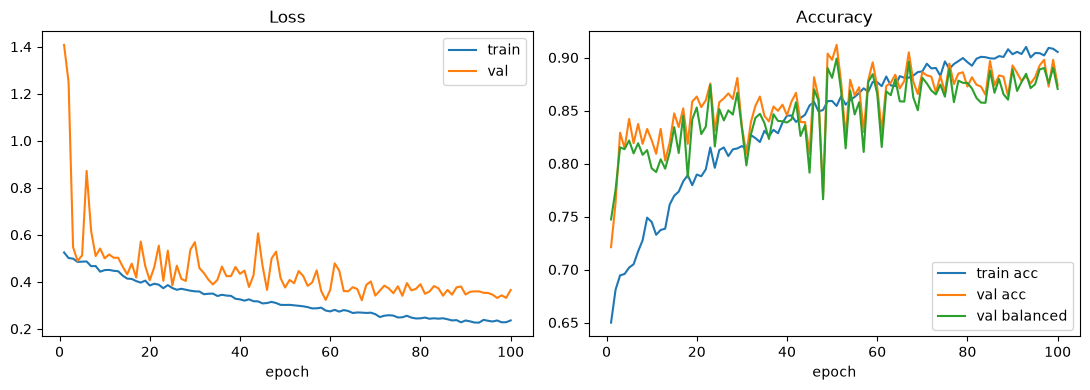

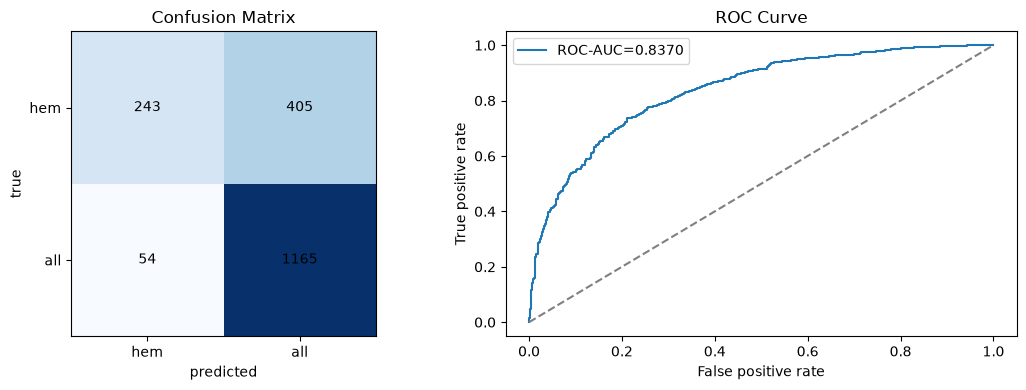

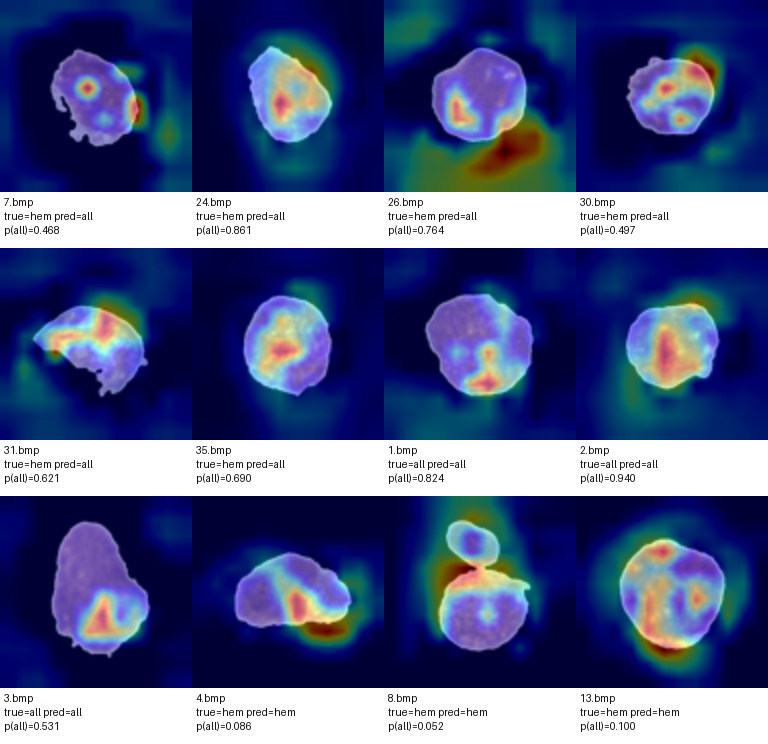

Saved outputs in: /Users/panshulaj/Documents/AIML proj/results/kaggle_compact_resnet_cnn_transformer_100ep
Grad-CAM contact sheet: /Users/panshulaj/Documents/AIML proj/results/kaggle_compact_resnet_cnn_transformer_100ep/gradcam_contact_sheet.png


In [7]:
OUT_DIR = PROJECT_ROOT / "results" / "kaggle_compact_resnet_cnn_transformer_100ep"
best_model, history_df, test_metrics, predictions = fit_model(model, OUT_DIR)
print(json.dumps(test_metrics, indent=2))
display(pd.Series(test_metrics).to_frame("value"))
print(classification_report(predictions["true_label"], predictions["predicted_label"], target_names=["hem_healthy", "all_leukemia"], zero_division=0))
plot_training_history(history_df, OUT_DIR)
plot_confusion_and_roc(test_metrics, predictions, OUT_DIR)
gradcam_sheet = make_gradcam_sheet(best_model, predictions, OUT_DIR, max_images=12)
print("Saved outputs in:", OUT_DIR)
print("Grad-CAM contact sheet:", gradcam_sheet)



## Notes

- Metrics above are produced by this executed notebook, not typed in manually.
- The final Kaggle testing folder is not scored because this Kaggle archive does not include labels for it.
- `all` is treated as leukemia and `hem` is treated as healthy, matching the training folder names and the validation CSV rows where original filenames end in `_all` or `_hem`.
